In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import random

In [3]:
print("GPU khả dụng:" , torch.cuda.is_available())
if torch.cuda.is_available():
    print("Tên GPU:", torch.cuda.get_device_name(0))

GPU khả dụng: True
Tên GPU: Tesla T4


In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers,models
(x_train, y_train), (x_test, y_test) = mnist.load_data()

(60000, 28, 28)

In [ ]:
def build_model_CNN(input_shape ,num_classes):
    model = models.Sequential() 
    model.add(layers.Conv2D(filters = 32,kernel_size = 3 ,activation ='relu', strides = 1, padding ='valid',
                            input_shape = input_shape))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))
    model.add(layers.Conv2D(filters = 64,kernel_size=(3,3)  ,activation = 'relu', strides = 1,
                            padding = 'valid'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

input_shape = (1,28,28)
num_classes = 10


In [15]:
model = build_model_CNN(input_shape=input_shape , num_classes=num_classes)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train, y_train,epochs= 50,batch_size= 320)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


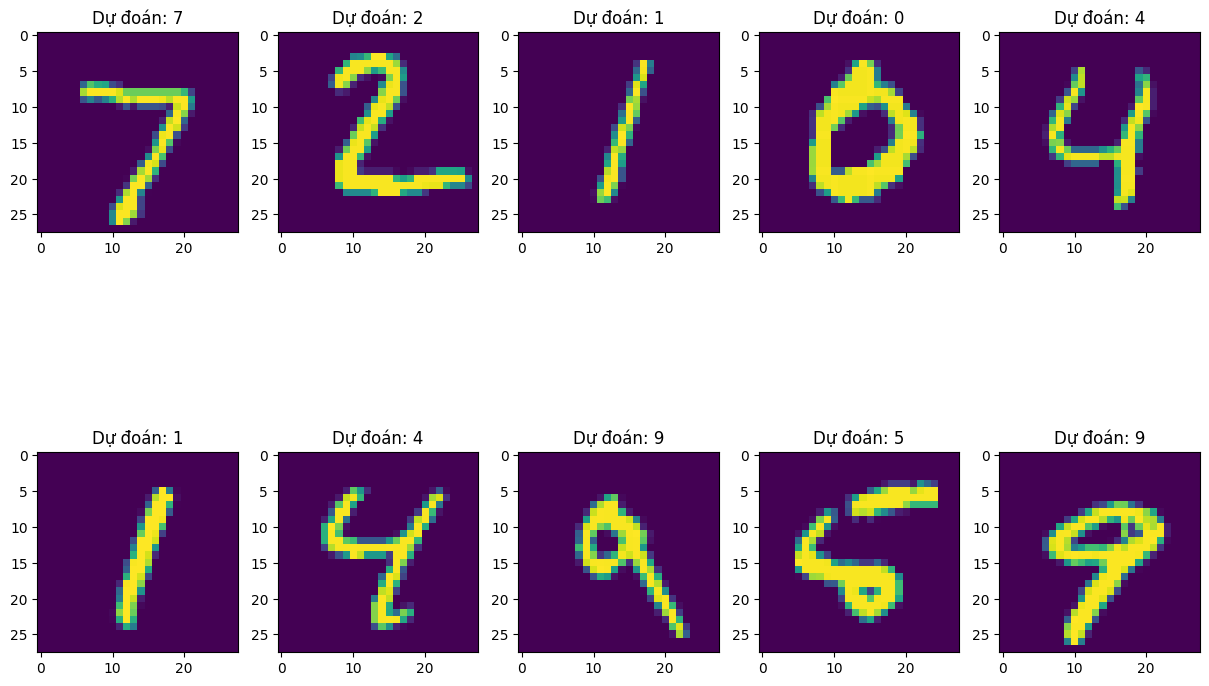

In [35]:
predictions = model.predict(x_test[:10])
plt.figure(figsize=(15,10))
for i in range(10):
    plt.subplot(2,5,i+1)
    predict_label = np.argmax(predictions[i])
    actual_label = np.argmax(y_test[i])
    plt.imshow(x_test[i])
    plt.title(f'Dự đoán: {predict_label}')
plt.show()

In [44]:
# Số classes trong tập MNIST
num_classes = 10

# Số epoch 
epochs = 10

# Các tham số cần thiết cho quá trình traning.
learning_rate = 0.01
batch_size = 3200
display_step = 10

# Tham số mạng CNN 
out_channel_1  = 64 # số channel của đầu ra conv thứ 1
out_channel_2 = 128 # số channel của đầu ra conv thứ 2

# Path lưu best model 
checkpoint = 'best_model.pth' # có thể để dạng *.pth

# Dataloader

In [38]:
# Transform image 
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
    ])

# load dataset từ torchvision.datasets
train_dataset = datasets.MNIST('../data', train=True, download=True,transform=transform)
test_dataset = datasets.MNIST('../data', train=False,transform=transform)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

# Model

- Input shape sẽ là: [-1, 28, 28, 1]. Ở đây -1 sẽ thể hiện batchsize, một batch thì gồm nhiều ảnh 28x28x1 (grayscale, số channel là 1 !)
- Chúng ta sẽ định nghĩa một model đơn giản gồm 2 lớp Conv đều có filter size là 3x3 và stride hãy set là 1. 
- Ngoài ra sẽ có một lớp maxpool, set filter size 2x2
- Flow như sau: conv2d_1 -> relu -> conv2d_2 -> relu -> maxpool2d -> dropout -> flatten -> linear1 -> relu -> dropout -> linear2


In [37]:
# Định nghĩa model 

model = nn.Sequential (
    nn.Conv2d(1, 32, kernel_size = 3, stride = 1),
    nn.ReLU(),
    nn.Conv2d(32, 64, kernel_size = 3, stride = 1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size = 2),
    nn.Dropout(0.25),
    nn.Flatten(),
    nn.Linear(9216, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 10)       
)

# load lại pretrained model (nếu có)
try:
  None
except:
  print("!!! Hãy train để có checkpoint file")

In [46]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
best_val_loss = 999
device = torch.device('cuda')
model.to(device)
for epoch in range(1,epochs):
    # Quá trình training 
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output,target)
        loss.backward()
        optimizer.step()
        if batch_idx % display_step == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tTrain Loss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
    # Quá trình testing 
    model.eval()
    test_loss = 0
    correct = 0
    # set no grad cho quá trình testing
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output =  model(data)# log softmax using F
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim = 1, keepdim = True) # argmax để lấy predicted label, chú ý keepdim = True
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader) 
    if test_loss < best_val_loss:
      best_val_loss = test_loss
      torch.save(model.state_dict(), 'best_model.pth')
      print("***********    TEST_ACC = {}%    ***********".format(correct))

Train Epoch: 1 [0/60000 (0%)]	Train Loss: 0.251853
Train Epoch: 1 [640/60000 (1%)]	Train Loss: 0.199351
Train Epoch: 1 [1280/60000 (2%)]	Train Loss: 0.127847
Train Epoch: 1 [1920/60000 (3%)]	Train Loss: 0.104542
Train Epoch: 1 [2560/60000 (4%)]	Train Loss: 0.090467
Train Epoch: 1 [3200/60000 (5%)]	Train Loss: 0.053958
Train Epoch: 1 [3840/60000 (6%)]	Train Loss: 0.388902
Train Epoch: 1 [4480/60000 (7%)]	Train Loss: 0.367356
Train Epoch: 1 [5120/60000 (9%)]	Train Loss: 0.312448
Train Epoch: 1 [5760/60000 (10%)]	Train Loss: 0.098679
Train Epoch: 1 [6400/60000 (11%)]	Train Loss: 0.102220
Train Epoch: 1 [7040/60000 (12%)]	Train Loss: 0.095738
Train Epoch: 1 [7680/60000 (13%)]	Train Loss: 0.269039
Train Epoch: 1 [8320/60000 (14%)]	Train Loss: 0.221233
Train Epoch: 1 [8960/60000 (15%)]	Train Loss: 0.374537
Train Epoch: 1 [9600/60000 (16%)]	Train Loss: 0.106256
Train Epoch: 1 [10240/60000 (17%)]	Train Loss: 0.188945
Train Epoch: 1 [10880/60000 (18%)]	Train Loss: 0.128736
Train Epoch: 1 [11520

In [ ]:
check_point = torch.load('best_model.pth')
for key,value in check_point.items():
    print(f"Tầng: {key} | Kích thước: {value.shape}")